In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

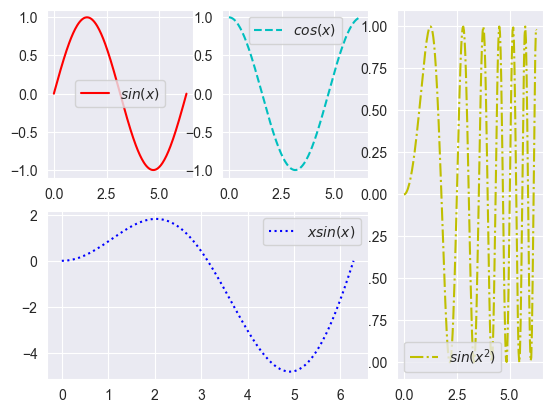

In [4]:
# Y1 = sin(x), Y2 = cos(x), Ys = sin（x^2）， Y4 = xsinx, x 属于[O, 2Π] 的组合图示例
x = np.linspace(0, 2*np.pi, 200)
y1 = np.sin(x)
y2 = np.cos(x)
y3 = np.sin(x*x)
y4 = np.sin(x)*x
ax1 = plt.subplot(2, 3, 1)
ax1.plot(x, y1, 'r', label='$sin(x)$')
plt.legend()
ax2 = plt.subplot(2, 3, 2)
ax2.plot(x, y2, 'c--', label='$cos(x)$')
plt.legend()
ax3 = plt.subplot2grid((2, 3), (0, 2), rowspan=2)  # 4,5窗口合并，用subplot会有警告
ax3.plot(x, y3, 'y-.', label='$sin(x^2)$')
plt.legend(loc="lower left")  # 上下 > 中间 > 左右
ax4 = plt.subplot2grid((2, 3), (1, 0), colspan=2)
ax4.plot(x, y4, 'b:', label='$xsin(x)$')
plt.legend()
plt.savefig('fig7.png', dpi=1500)
plt.show()

In [7]:
# 使用该段指令下载 seaborn 中的 titanic 数据，并输出数据保存的位置
titanic = sns.load_dataset('titanic')
print(sns.utils.get_data_home())

TimeoutError: [WinError 10060] 由于连接方在一段时间后没有正确答复或连接的主机没有反应，连接尝试失败。

In [5]:
df = pd.read_csv("titanic.csv")
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [12]:
plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

In [26]:
df_survived = df.groupby('class')['survived'].sum().reset_index()
df_survived

,class,survived
0,First,136
1,Second,87
2,Third,119


In [27]:
df_total = df.groupby('class')['survived'].count().reset_index()
df_total

,class,survived
0,First,216
1,Second,184
2,Third,491


In [28]:
df_merge = pd.merge(
    df_survived, 
    df_total, 
    on = 'class'
)
df_merge

,class,survived_x,survived_y
0,First,136,216
1,Second,87,184
2,Third,119,491


In [29]:
df_merge.rename(
    columns = {'survived_x': 'survived', 'survived_y': 'total'}, 
    inplace = True
)
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   class     3 non-null      object
 1   survived  3 non-null      int64 
 2   total     3 non-null      int64 
dtypes: int64(2), object(1)
memory usage: 200.0+ bytes


In [30]:
df_merge['survived_percent'] = df_merge['survived'] / df_merge['total']
df_merge

,class,survived,total,survived_percent
0,First,136,216,0.629630
1,Second,87,184,0.472826
2,Third,119,491,0.242363


Text(0.5, 1.0, 'titanic各舱位幸存比例')

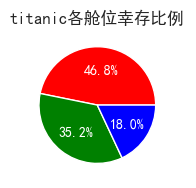

In [39]:
ax1 = plt.subplot(2, 3, 1)
ax1.set_aspect(aspect='equal')  # 设置横纵轴比例相等，保证饼图是圆形
ax1.pie(x=df_merge['survived_percent'], labels=df_merge['class'], colors=['r', 'g', 'b'], autopct="%.1f%%", textprops={'color':'white'})
ax1.set_title("titanic各舱位幸存比例")

# dt 访问器（Accessor）

用于对包含日期时间（datetime）或时间增量（timedelta）类型的 Series 或 DataFrame 列进行向量化操作。

常用的 dt 访问器属性和方法
以下是一些常用的 dt 访问器属性和方法：

属性（直接提取日期时间的组成部分）：

dt.year：年份（整数）

dt.month：月份（1-12）

dt.day：日期（1-31）

dt.hour：小时（0-23）

dt.minute：分钟（0-59）

dt.second：秒（0-59）

dt.dayofweek：星期几（0 = 周一，6 = 周日）

dt.day_name()：星期几的名称（如 'Monday', 'Tuesday'）

dt.month_name()：月份名称（如 'January', 'February'）

dt.is_leap_year：是否为闰年（布尔值）

dt.quarter：季度（1-4）

方法（对日期时间进行计算或转换）：

dt.strftime(format)：将日期时间格式化为字符串（如 dt.strftime('%Y-%m-%d')）

dt.date：返回日期部分（不含时间）

dt.time：返回时间部分（不含日期）

dt.round(freq)：对日期时间进行舍入（如 dt.round('H') 表示舍入到小时）

dt.floor(freq)：向下舍入到最近的频率

dt.ceil(freq)：向上舍入到最近的频率

dt.tz_convert(tz)：转换时区（需要时区信息）

 agg(或aggregate)({'列名': '聚合函数', '列名': '聚合函数'})，参数为字典

groups 用法：在 Pandas 的 groupby 对象中，groups 是一个属性，它返回一个字典，其中键是分组的名称（即分组依据列的不同取值），值是对应组的索引标签（从0开始）。（使用groupby后才能使用groups）

keys():无参数，返回字典的 键 (不要漏 s )

get_group 用法：是 groupby 对象的一个方法，用于获取指定分组键对应的组数据（获取字典的值）。它接受一个参数，即分组键的值。

gca()函数：全称是 get current axes，意思是获取当前的坐标轴对象。在一个图形中可能包含多个子图（由 subplot 等函数创建），gca() 会返回当前正在操作的那个坐标轴对象。通过这个坐标轴对象，可以对图形的坐标轴进行各种设置，比如设置坐标轴标签、刻度、标题等。

gcf() 函数：全称是 get current figure，用于获取当前的 Figure 对象。Figure 对象是 Matplotlib 中图形的顶层容器，一个 Figure 可以包含多个 Axes（子图）对象。通过 gcf() 获取到 Figure 对象后，可以对整个图形进行一些设置，比如设置图形的大小、分辨率等。

axes 是包含数据绘图区域以及相关元素（标题、坐标轴标签等）的子图
 
axis 是构成 axes 的单个坐标轴（x 轴或 y 轴）

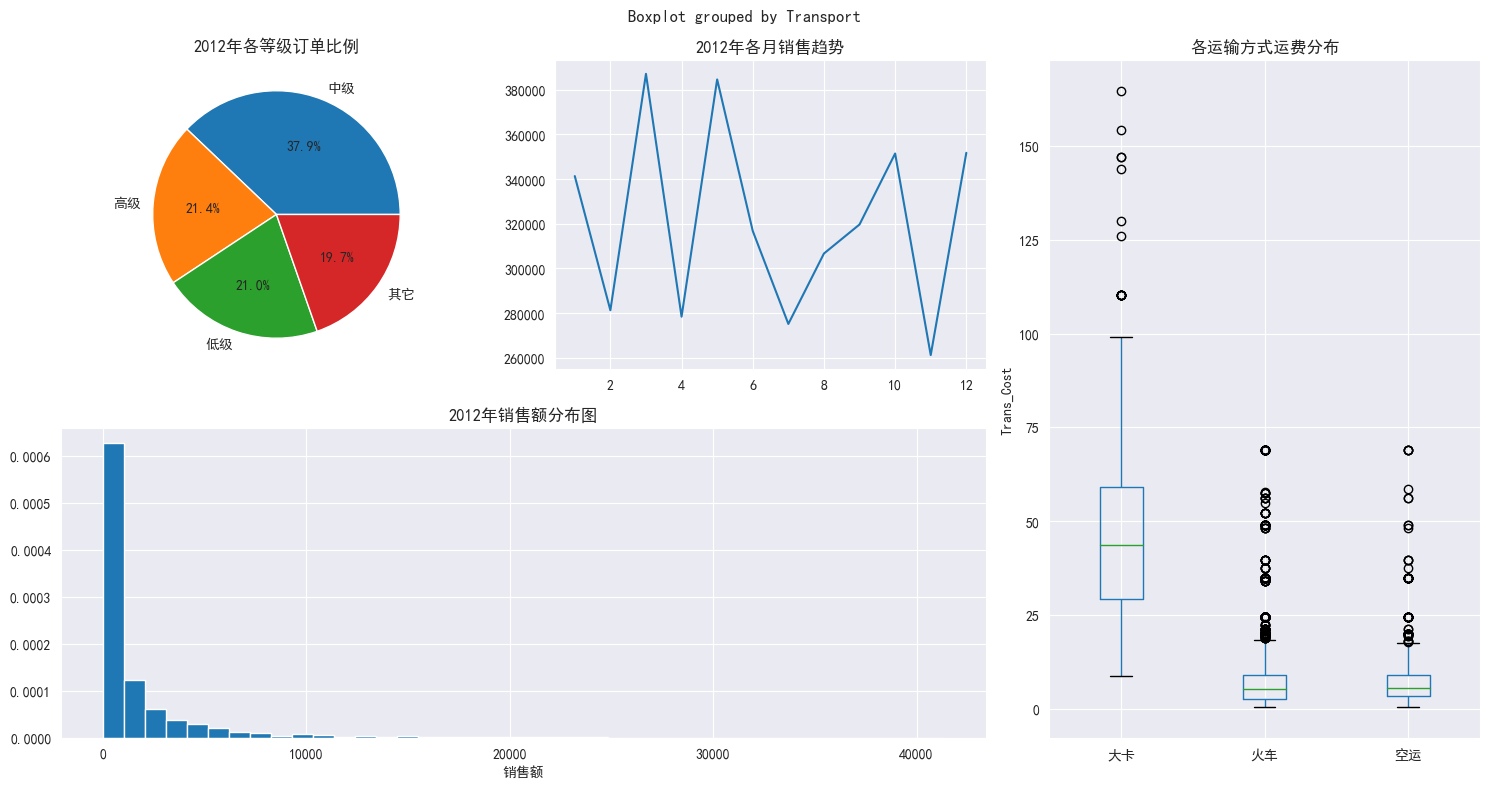

In [84]:
# 1. 读入数据
df = pd.read_excel("Trade.xlsx")          

# 2. 新增年月字段
df['year']  = df['Date'].dt.year          
df['month'] = df['Date'].dt.month

# 3. 中文字体
plt.rcParams['font.family'] = 'SimHei'    
plt.rcParams['axes.unicode_minus'] = False

# 4. 建立 2×3 画布（统一用 plt.subplot，便于后续 savefig 对齐）
plt.figure(figsize=(15, 8))

# —— 子图 1：2012 年各等级订单占比饼图
ax1 = plt.subplot(2, 3, 1)
# pandas中的value.count：统计频数：对 Series 中的每个唯一值进行计数，返回每个值出现的次数，loc[row, col]
class_counts  = df.loc[df['year'] == 2012, 'Order_Class'].value_counts()
class_percent = class_counts / class_counts.sum()
ax1.set_aspect('equal')  # 确保饼图是圆形
ax1.pie(class_percent,
        labels=class_percent.index,
        autopct='%.1f%%')
ax1.set_title('2012年各等级订单比例')

# —— 子图 2：2012 年各月销售趋势（Pandas 原生绘图，自带图例）
ax2 = plt.subplot(2, 3, 2)
# .to_frame()把刚才的 Series 转成单列的 DataFrame，列名还是 "Sales"，索引是 1~12 的月份
month_sales = (df[df['year'] == 2012]
               .groupby('month')['Sales']
               .sum()
               .to_frame())
month_sales.plot(ax=ax2, legend=False, title='2012年各月销售趋势')
ax2.set_xlabel('')

# —— 子图 3：不同运输方式运费箱线图（用 Pandas 自带 boxplot，自带图例）
"""
pandas 的 boxplot：
 df.boxplot(column='Trans_Cost',       # 要画箱线图的数值列
           by='Transport',           # 分组键（类别型）
           ax=ax3)                   # 可选：画到已有子图
"""
ax3 = plt.subplot(2, 3, (3, 6))
df.boxplot(column='Trans_Cost', by='Transport', ax=ax3)
ax3.set_title('各运输方式运费分布')
ax3.set_xlabel('')  # 已经有行标签by='Transport'，键
ax3.set_ylabel('Trans_Cost')

# —— 子图 4：2012 年销售额直方图
ax4 = plt.subplot(2, 3, (4, 5))
ax4.hist(df.loc[df['year'] == 2012, 'Sales'],
         bins=40, density=True)
ax4.set_title('2012年销售额分布图')
ax4.set_xlabel('销售额')

# 5. 保存 & 显示
plt.tight_layout()
plt.savefig('figure1.png', dpi=500)
plt.show()